In [ ]:
import random

budget = 3000
days = 3
mode = "balanced"   

places = [
    {"name": "Museum", "cost": 500, "crowd": 3, "time": 2},
    {"name": "Park", "cost": 200, "crowd": 1, "time": 1},
    {"name": "Fort", "cost": 400, "crowd": 2, "time": 2},
    {"name": "Beach", "cost": 300, "crowd": 2, "time": 3},
    {"name": "Mall", "cost": 600, "crowd": 3, "time": 2},
]

def create_plan(budget, days, places):
    plan = []
    remaining = budget
    used = set()

    places_copy = places.copy()
    random.shuffle(places_copy)

    for _ in range(days):
        for place in places_copy:
            if place["name"] not in used and place["cost"] <= remaining:
                plan.append(place)
                remaining -= place["cost"]
                used.add(place["name"])
                break

    return plan


def utility(plan, mode="balanced"):
    enjoyment = len(plan) * 10
    cost = sum(p["cost"] for p in plan)
    crowd = sum(p["crowd"] for p in plan)
    time = sum(p["time"] for p in plan)

    if mode == "cheap":
        return enjoyment - 0.2 * cost - crowd - time
    elif mode == "luxury":
        return enjoyment * 1.5 - 0.05 * cost - 0.5 * crowd
    else:  
        return enjoyment - 0.1 * cost - crowd - time


def should_replan(old_plan, new_plan, threshold=2):
    return (utility(new_plan, mode) - utility(old_plan, mode)) > threshold


def generate_event():
    return random.choice([
        "none",
        "closed",
        "price_surge",
        "discount",
        "traffic_delay"
    ])


plan = create_plan(budget, days, places)
replans = 0
history = []


best_plan = plan
best_utility = utility(plan, mode)

print("Initial Plan:")
print([p["name"] for p in plan])

for step in range(5):

    print(f"\n--- Step {step+1} ---")

    event = generate_event()
    print("Event:", event)

    new_places = [p.copy() for p in places]

    # Apply event effects
    if event == "closed":
        new_places = [p for p in new_places if p["name"] != "Museum"]

    elif event == "price_surge":
        for p in new_places:
            p["cost"] += 200

    elif event == "discount":
        for p in new_places:
            p["cost"] = max(50, p["cost"] - 100)

    elif event == "traffic_delay":
        for p in new_places:
            p["time"] += 2

    new_plan = create_plan(budget, days, new_places)

    old_utility = utility(plan, mode)
    new_utility = utility(new_plan, mode)

    print("Old Utility:", old_utility)
    print("New Utility:", new_utility)

    
    if new_utility > best_utility:
        best_plan = new_plan
        best_utility = new_utility

    if should_replan(plan, new_plan):
        plan = new_plan
        replans += 1
        print("✅ Agent replanned")
    else:
        print("❌ Agent kept plan")

    print("Current Plan:", [p["name"] for p in plan])

    history.append({
        "step": step + 1,
        "event": event,
        "old_utility": old_utility,
        "new_utility": new_utility,
        "plan": [p["name"] for p in plan]
    })


print("\n===== FINAL OUTPUT =====")
print("Final Plan:", [p["name"] for p in plan])
print("Final Utility:", utility(plan, mode))
print("Total Replans:", replans)

print("\n===== BEST PLAN FOUND =====")
print("Best Plan Found:", [p["name"] for p in best_plan])
print("Best Utility:", best_utility)

Initial Plan:
['Fort', 'Beach', 'Museum']

--- Step 1 ---
Event: price_surge
Old Utility: -104.0
New Utility: -164.0
❌ Agent kept plan
Current Plan: ['Fort', 'Beach', 'Museum']

--- Step 2 ---
Event: discount
Old Utility: -104.0
New Utility: -74.0
✅ Agent replanned
Current Plan: ['Fort', 'Museum', 'Beach']

--- Step 3 ---
Event: discount
Old Utility: -74.0
New Utility: -104.0
❌ Agent kept plan
Current Plan: ['Fort', 'Museum', 'Beach']

--- Step 4 ---
Event: price_surge
Old Utility: -74.0
New Utility: -185.0
❌ Agent kept plan
Current Plan: ['Fort', 'Museum', 'Beach']

--- Step 5 ---
Event: none
Old Utility: -74.0
New Utility: -101.0
❌ Agent kept plan
Current Plan: ['Fort', 'Museum', 'Beach']

===== FINAL OUTPUT =====
Final Plan: ['Fort', 'Museum', 'Beach']
Final Utility: -74.0
Total Replans: 1

===== BEST PLAN FOUND =====
Best Plan Found: ['Fort', 'Museum', 'Beach']
Best Utility: -74.0


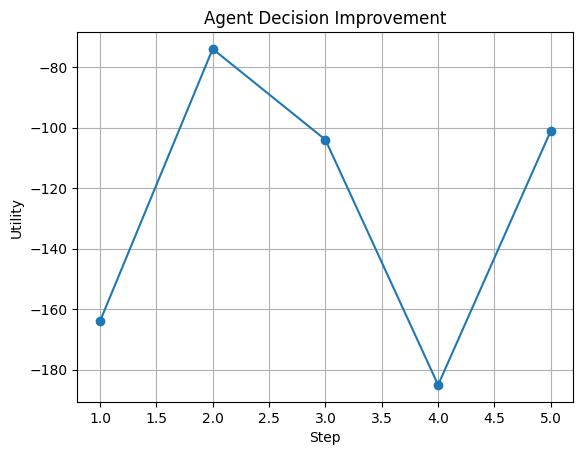

In [15]:
import matplotlib.pyplot as plt

steps = [h["step"] for h in history]
utilities = [h["new_utility"] for h in history]

plt.plot(steps, utilities, marker='o')
plt.xlabel("Step")
plt.ylabel("Utility")
plt.title("Agent Decision Improvement")
plt.grid()
plt.show()

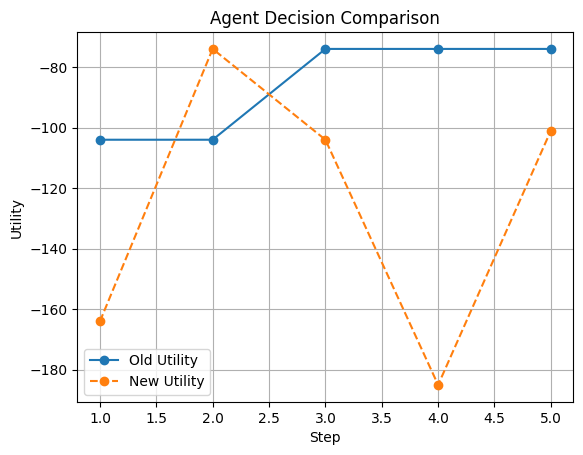

In [16]:
import matplotlib.pyplot as plt

steps = [h["step"] for h in history]
old_utils = [h["old_utility"] for h in history]
new_utils = [h["new_utility"] for h in history]

plt.plot(steps, old_utils, marker='o', label="Old Utility")
plt.plot(steps, new_utils, marker='o', linestyle='--', label="New Utility")

plt.xlabel("Step")
plt.ylabel("Utility")
plt.title("Agent Decision Comparison")
plt.legend()
plt.grid()
plt.show()